# Continuous-time Physics-Informed Neural Network (PINN) for Burgers' Equation

Reproduces: Raissi, Perdikaris & Karniadakis (2019), *Physics-informed neural networks*,
Appendix A.1 (Fig. A.6 / Table A.1 benchmark).

**PDE (Burgers' equation):**

$$u_t + u\,u_x - \nu\, u_{xx} = 0, \qquad x \in [-1,1],\ t \in [0,1], \qquad \nu = \frac{0.01}{\pi}$$

$$u(0,x) = -\sin(\pi x), \qquad u(t,-1) = u(t,1) = 0$$

**Benchmark configuration:** $N_u=100$ initial/boundary points, $N_f=10{,}000$ collocation points,
9 hidden layers $\times$ 20 neurons, $\tanh$ activations, trained with L-BFGS.
Paper's reported relative $\mathbb{L}_2$ error vs. the exact solution: $6.7\times 10^{-4}$.

In [23]:


import numpy as np
import torch
import torch.nn as nn
from scipy.stats import qmc
from scipy.io import loadmat
import matplotlib.pyplot as plt


# --------------------------------------------------------------------------
# SETUP: import the tools we need, fix the random seed so results are
# reproducible, and choose whether to run on Apple's GPU (MPS) or the CPU.
#
# Then load a pre-computed reference solution for Burgers' equation from a
# file. This is the "correct answer", generated independently using a
# traditional numerical method - we only use it to check our neural
# network's accuracy at the very end, not to train it.
#   x          = the 256 spatial points the solution is known at
#   t          = the 100 time points the solution is known at
#   usol_exact = the known solution u(x,t) at every (x,t) combination
#   nu_pde     = a fixed constant that appears in Burgers' equation itself
# --------------------------------------------------------------------------

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# -----------------------------------------------------------------------
# 1. Load reference data
# -----------------------------------------------------------------------
data = loadmat("/Users/adiljan/desktop/research-internship/PINNs/appendix/Data/burgers_shock.mat")
x = data["x"].flatten()[:, None]      # (256, 1)   spatial grid, in [-1, 1]
t = data["t"].flatten()[:, None]      # (100, 1)   time grid,   in [0, 1]
usol_exact = data["usol"]             # (256, 100) u(x_i, t_j)  -- rows=x, cols=t

nu_pde = 0.01 / np.pi                 # diffusion coefficient in the PDE



In [10]:
# -----------------------------------------------------------------------
# 2. Build training data: IC/BC points (N_u) + collocation points (N_f)
# --------------------------------------------------------------------------
# BUILD TRAINING DATA: two very different piles of points.
#
# First, build a grid covering the whole domain (all combinations of x and
# t), and flatten it alongside the true solution - this full grid (X_star,
# u_star) isn't used for training; it's kept aside for the final accuracy
# check at the end, same as the raw file loaded in Step 1.
#
# Pile 1 - "known answer" points (100 of them):
#   Pull out the points where we actually know the correct answer: the
#   starting condition at t=0 (xx1/uu1), and the two edges of the domain
#   at x=-1 and x=1, where the solution is always 0 (xx2/uu2, xx3/uu3).
#   Combine all of these candidates, then randomly keep only N_u=100 of
#   them - this is the only real "data" the network is ever shown.
# ----------------------------------------------------------------------------

N_u = 100
N_f = 10000

X, T = np.meshgrid(x, t)              # X, T shape: (100, 256) i.e. (len(t), len(x))
X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))   # all (x,t) pairs
u_star = usol_exact.T.flatten()[:, None]   # transpose so it matches X_star ordering

lb = X_star.min(0)   # domain lower bound  [x_min, t_min]
ub = X_star.max(0)   # domain upper bound  [x_max, t_max]

# Initial condition: t = 0, all x, u = -sin(pi*x) 
xx1 = np.hstack((X[0:1, :].T, T[0:1, :].T))     # (256, 2): (x, t=0)
uu1 = usol_exact[:, 0:1]                        # (256, 1): u(x, 0)

# Boundary condition: x = -1, all t, u = 0 
xx2 = np.hstack((X[:, 0:1], T[:, 0:1]))         # (100, 2): (x=-1, t)
uu2 = usol_exact[0:1, :].T                      # (100, 1)

# Boundary condition: x = 1, all t, u = 0 
xx3 = np.hstack((X[:, -1:], T[:, -1:]))         # (100, 2): (x=1, t)
uu3 = usol_exact[-1:, :].T                      # (100, 1)

X_u_train = np.vstack([xx1, xx2, xx3])          # all IC/BC candidate points
u_train_all = np.vstack([uu1, uu2, uu3])

# Randomly sample N_u of these IC/BC points (paper: "randomly distributed" data)
idx = np.random.choice(X_u_train.shape[0], N_u, replace=False)
X_u_train = X_u_train[idx, :]
u_train = u_train_all[idx, :]

# -------------------------------------------------------------------------
# Pile 2: "physics check" points (10,000 of them):
#   Scatter 10,000 points randomly (but evenly, via Latin Hypercube
#   Sampling) across the entire domain. These points carry NO known
#   answer - they're only used later to check whether the network's
#   guess obeys the physics equation at that location.
# --------------------------------------------------------------------------

sampler = qmc.LatinHypercube(d=2, seed=1234)
sample = sampler.random(n=N_f)
X_f_train = lb + (ub - lb) * sample             # scale unit cube to [lb, ub]
X_f_train = np.vstack([X_f_train, X_u_train])   # standard practice: include IC/BC pts too


In [11]:
# -----------------------------------------------------------------------
# 3. Neural network: 2 inputs (x,t) -> 9 hidden layers x 20 neurons -> 1 output (u)
# --------------------------------------------------------------------------
# BUILD THE GUESSER: this defines the neural network itself - the thing
# that will take in a (time, position) pair and output its current best
# guess for the solution there. Right now it knows nothing; it only learns
# once we train it in Step 7.
#
# Structure: it takes 2 numbers in (x and t), passes them through 9 hidden
# layers of 20 "neurons" each, and produces 1 number out (its guess for u).
# Each layer uses a "tanh" activation, a specific curve-shaped function
# chosen because it stays smooth enough to be differentiated twice later
# (needed for the physics check in Step 4) - a more common choice like
# ReLU would break that.
#
# Before the input reaches the network, it's rescaled to sit between -1
# and 1 (using the domain boundaries lb/ub from Step 2). This isn't
# optional polish - tanh-based networks train much more reliably when
# their inputs are kept in this range. Outside the S-curve range Outside that range, 
# it flattens out almost completely, meaning two very different large inputs would 
# produce nearly identical outputs, making it hard for the network to tell them apart 
# or to learn useful gradients from them.
#
# The weights are initialized using a standard method ("Xavier") that
# keeps the network's starting guesses from being wildly too large or
# too small, which helps training get off to a stable start.
#
# Finally: if a previously-trained version of this network was saved to
# disk (e.g. from an earlier run), load it back in and continue from
# there instead of starting over from scratch.
# Worth to note: It is optional to resume from a checkpoint if you're training across multiple
# sessions (e.g. if a long background job gets interrupted). Just rerun
# this script , it will pick up from where it left off.
# --------------------------------------------------------------------------

class PINN(nn.Module):
    def __init__(self, layers, lb, ub):
        super().__init__()
        self.lb = torch.tensor(lb, dtype=torch.float32, device=device)
        self.ub = torch.tensor(ub, dtype=torch.float32, device=device)

        modules = []
        for i in range(len(layers) - 2):
            linear = nn.Linear(layers[i], layers[i + 1])
            nn.init.xavier_normal_(linear.weight)   # Xavier init, as in paper's TF1 code
            nn.init.zeros_(linear.bias)
            modules.append(linear)
            modules.append(nn.Tanh())
        out_linear = nn.Linear(layers[-2], layers[-1])
        nn.init.xavier_normal_(out_linear.weight)
        nn.init.zeros_(out_linear.bias)
        modules.append(out_linear)

        self.net = nn.Sequential(*modules)

    def forward(self, x, t):
        # normalize inputs to [-1, 1] - standard PINN practice for tanh net stability
        X = torch.cat([x, t], dim=1)
        X = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        return self.net(X)


layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 20, 1]   # 9 hidden layers x 20 neurons
model = PINN(layers, lb, ub).to(device)

import os
CKPT = "pinn_burgers_model2.pt"
if os.path.exists(CKPT):
    model.load_state_dict(torch.load(CKPT))
    print(f"Resumed from checkpoint {CKPT}")



Resumed from checkpoint pinn_burgers_model1.pt


In [12]:
# -----------------------------------------------------------------------
# 4. Physics-informed residual f(t,x) via automatic differentiation
# --------------------------------------------------------------------------
# BUILDING THE PHYSICS CHECKER: this is the step that makes this a
# "physics-informed" network. 
#
# net_u() is just a shortcut name for "ask the network for its guess".
#
# net_f() takes that guess and automatically works out how it's changing
# over time (u_t), how it's changing over position (u_x), and how THAT
# rate of change is itself changing over position (u_xx) - all without
# us writing any calculus by hand; PyTorch calculates these for us
# because it already tracked every operation the network performed.
#
# Those three rates are then combined into a single number, f, using the
# exact formula from Burgers' equation. If the network's guess perfectly
# obeys the physics at that point, f comes out as 0. If the guess is
# wrong, f tells us by how much the physics is being broken there - and
# this is the number we'll try to drive to zero during training.
# --------------------------------------------------------------------------

def net_u(x, t):
    return model(x, t)

def net_f(x, t):
    """ f := u_t + u*u_x - nu*u_xx    (should be ~0 everywhere if PDE is satisfied) """
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u = net_u(x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                create_graph=True)[0]

    f = u_t + u * u_x - nu_pde * u_xx
    return f


# -----------------------------------------------------------------------
# 5. Convert data to torch tensors
# --------------------------------------------------------------------------
# CONVERT DATA TO THE RIGHT FORMAT: 
# Everything built in Step 2 (the two piles of points) currently exists as
# plain NumPy arrays. PyTorch needs its own data format ("tensors") to do
# any of its calculations, including the automatic differentiation used
# in Step 4, so this just repackages the same numbers into that format,
# split out by x and t, and ready to be fed into the network.
# --------------------------------------------------------------------------

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32, device=device)

x_u = to_tensor(X_u_train[:, 0:1])
t_u = to_tensor(X_u_train[:, 1:2])
u_target = to_tensor(u_train)

x_f = to_tensor(X_f_train[:, 0:1])
t_f = to_tensor(X_f_train[:, 1:2])



In [13]:
# -----------------------------------------------------------------------
# 6. Loss function: MSE_u (data) + MSE_f (physics residual)
# -----------------------------------------------------------------------
# COMBINE THE TWO KINDS OF "WRONGNESS" INTO ONE SCORE:
#
# loss_u: ask the network to guess at the 100 known points (pile 1), and
#         measure how far off those guesses are from the real answers.
#
# loss_f: ask the physics checker (Step 4) to evaluate the 10,000
#         scattered points (pile 2), and measure how far its output is
#         from the 0 it should be if the physics is being obeyed.
#
# Adding loss_u and loss_f together gives one single number that captures
# both kinds of mistakes at once - this is the number we want to shrink
# as close to zero as possible during training.
# --------------------------------------------------------------------------

mse = nn.MSELoss()

def loss_fn():
    u_pred = net_u(x_u, t_u)
    f_pred = net_f(x_f, t_f)
    loss_u = mse(u_pred, u_target)
    loss_f = mse(f_pred, torch.zeros_like(f_pred))
    return loss_u + loss_f, loss_u, loss_f

# -----------------------------------------------------------------------
# 7. Train with L-BFGS (full-batch, quasi-Newton, as in the paper)
# -----------------------------------------------------------------------
# ACTUALLY TRAIN THE NETWORK: repeatedly adjust its internal settings to
# make the combined score from Step 6 as small as possible.
#
# L-BFGS is the specific method used to do this adjusting: rather than
# taking small cautious steps like many common training methods do, it
# tries to take smarter, more targeted steps toward a good answer, which
# works well here because we're not dealing with a huge amount of data.
#
# "closure" is just the piece of code L-BFGS calls over and over: each
# time, it asks "what's the current score, and which direction should I
# adjust things to make it smaller?" - and every 100 of these calls, we
# print out the current score so we can watch progress happen live.
#
# Running this cell is what actually does the learning, everything
# before this point only set the pieces up.
# --------------------------------------------------------------------------

optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=5000,
    max_eval=5000,
    history_size=50,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    line_search_fn="strong_wolfe",
)

iteration = [0]

def closure():
    optimizer.zero_grad()
    loss, loss_u, loss_f = loss_fn()
    loss.backward()
    iteration[0] += 1
    if iteration[0] % 100 == 0:
        print(f"iter {iteration[0]:5d}  loss={loss.item():.4e}  "
              f"loss_u={loss_u.item():.4e}  loss_f={loss_f.item():.4e}")
    return loss

print("Training with L-BFGS ...")
optimizer.step(closure)


Training with L-BFGS ...


tensor(2.5424e-06, device='mps:0', grad_fn=<AddBackward0>)


Relative L2 error: 5.717831e-04
Paper's reported benchmark (N_u=100, N_f=10000, 9x20): 6.7e-4


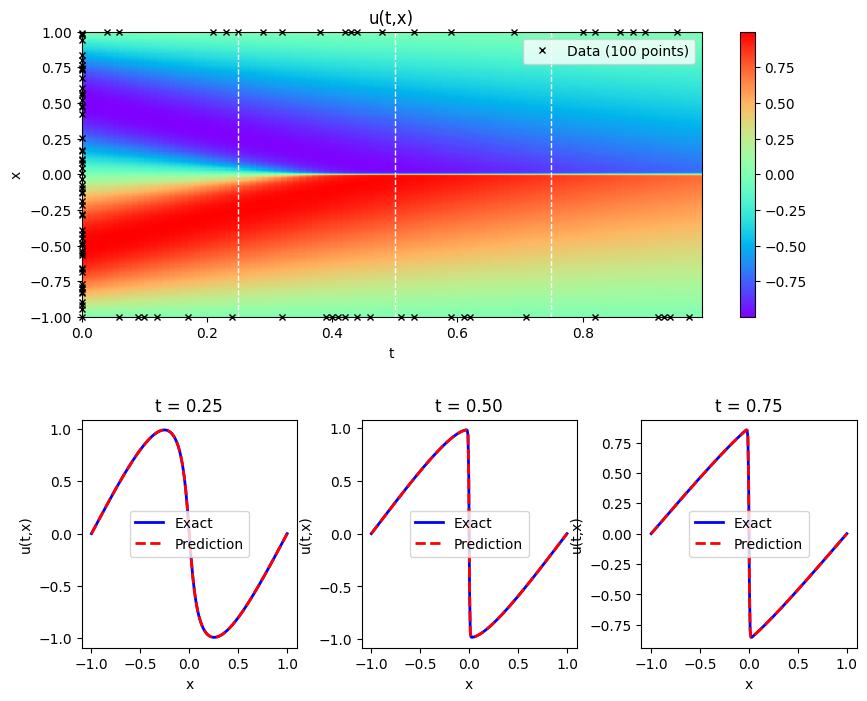

Saved figure to burgers_pinn_full_figure.png


In [14]:
# -----------------------------------------------------------------------
# 8. Evaluate: relative L2 error against the FULL reference grid
# -----------------------------------------------------------------------
# CHECK AGAINST THE ANSWER KEY: now that training is done, ask the network
# for its guess at every single point in the full reference grid (X_star)
# i.e the same full grid we set aside back in Step 2, including all the
# points it never saw during training.
#
# We then compare that guess against the true solution (u_star, loaded
# from the .mat file in Step 1) using a single summary number: how far
# off the predictions are overall, relative to the overall size of the
# true solution. A small number here means an accurate network.
#
# We print this next to the paper's own reported accuracy for the same
# setup, so we can see directly how we compare.
#
# Finally, save both the network's predictions and the trained network
# itself to disk. The saved network is what lets us resume training
# later (as set up back in Step 3) instead of starting over.
# --------------------------------------------------------------------------
model.eval()
x_star = to_tensor(X_star[:, 0:1])
t_star = to_tensor(X_star[:, 1:2])
with torch.no_grad():
    u_pred_star = net_u(x_star, t_star).cpu().numpy()

error_u = np.linalg.norm(u_star - u_pred_star, 2) / np.linalg.norm(u_star, 2)
print(f"\nRelative L2 error: {error_u:.6e}")
print(f"Paper's reported benchmark (N_u=100, N_f=10000, 9x20): 6.7e-4")

np.save("u_pred_star.npy", u_pred_star)
torch.save(model.state_dict(), "pinn_burgers_model2.pt")

# -----------------------------------------------------------------------
# 9. Plot: reproduce Fig. A.6 - heatmap with training data + 3 snapshots
# -----------------------------------------------------------------------
# VISUALIZE THE RESULT: turn the numbers from Step 8 into pictures.
#
# Top picture: the entire solution across all of time and position at
# once, with the 100 known training points marked as black x's, so you
# can see exactly where the network's "known answers" came from relative
# to the whole picture.
#
# Bottom three pictures: a closer look at three specific moments in time,
# comparing the true solution (solid blue) against the network's
# prediction (dashed red) side by side. If the dashed line sits almost
# exactly on top of the solid line, including through the sharp drop
# near the middle - that's a strong visual sign the network learned the
# physics correctly and not just a rough average.
# --------------------------------------------------------------------------


x_flat = x.flatten()
t_flat = t.flatten()
u_pred_grid = u_pred_star.reshape(len(t_flat), len(x_flat))  # (t, x)

fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.8], hspace=0.4, wspace=0.3)

# Top panel: full heatmap with training data overlay
ax0 = fig.add_subplot(gs[0, :])
h = ax0.imshow(usol_exact, interpolation='nearest', cmap='rainbow',
               extent=[t_flat.min(), t_flat.max(), x_flat.min(), x_flat.max()],
               origin='lower', aspect='auto')
fig.colorbar(h, ax=ax0)
ax0.plot(X_u_train[:, 1], X_u_train[:, 0], 'kx', markersize=4, clip_on=False,
         label=f'Data ({X_u_train.shape[0]} points)')
for t_val in [0.25, 0.50, 0.75]:
    ax0.axvline(t_val, color='w', linestyle='--', linewidth=1)
ax0.set_xlabel('t')
ax0.set_ylabel('x')
ax0.set_title('u(t,x)')
ax0.legend(loc='upper right')

# Bottom panel: snapshot comparisons 
for i, t_val in enumerate([0.25, 0.50, 0.75]):
    ax = fig.add_subplot(gs[1, i])
    idx_t = np.argmin(np.abs(t_flat - t_val))
    ax.plot(x_flat, usol_exact[:, idx_t], 'b-', linewidth=2, label='Exact')
    ax.plot(x_flat, u_pred_grid[idx_t, :], 'r--', linewidth=2, label='Prediction')
    ax.set_title(f"t = {t_flat[idx_t]:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(t,x)")
    ax.legend()

plt.savefig("burgers_pinn_full_figure.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure to burgers_pinn_full_figure.png")